In [1]:
# import packages
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
import pystac
import pystac_client
import stackstac
import matplotlib.pyplot as plt
import xarray as xr
from datetime import datetime
import matplotlib
import ipyleaflet
import sys
import os
import dask_gateway
import dask
import planetary_computer
#from rechunker import rechunk
# path to 'sar_snowmelt_timing' directory'
sys.path.append('sar_snowmelt_timing')
import s1_rtc_bs_utils
import contextily as ctx
import rioxarray as rxr
#import skimage
import glob
import matplotlib.transforms as mtransforms
import re
import scipy
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100
import os

In [3]:
# load bozeman creek geometry 
gj = os.path.join('bozeman_creek.geojson')
bbox_gdf = gpd.read_file(gj)


In [4]:
# years for analysis. Satellite launched and collected data starting in 2015
years = [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]


In [5]:
# use s1_rtc_bs_utils package to initialize start time, end time, polarization, spatial resolution
# this pulls the data form the planetary computer.
# vv polarization and 10m resolution
ts_ds = s1_rtc_bs_utils.get_s1_rtc_stac_pc(bbox_gdf,
                                           start_time='2014-01-01',
                                           end_time=datetime.today().strftime('%Y-%m-%d'),
                                           polarization='vv',
                                           resolution=10)


/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/stackstac/prepare.py:408: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  times = pd.to_datetime(


In [6]:
# correct watershed boundary crs
bozeman_watershed = gpd.read_file('bozeman_creek.geojson').to_crs(ts_ds.crs)

# clip SAR output to watershed boundary 
ts_ds_clipped = ts_ds.rio.clip(bozeman_watershed.geometry,bozeman_watershed.crs)


In [7]:
###  VV POLARIZATION 10M RESOLUTION ###

# process for each year 
# specify only 'melt season' months 

for year in years:
    # to see which year is being processed
    print(f'Processing {year}...')
    # each year's melt season - maybe change this
    melt_year = slice(f'{year}-02-01',f'{year}-05-31')

    # analyze each year
    oneyear = ts_ds_clipped.sel(time=melt_year)
        
    # get medians
    runoffs = s1_rtc_bs_utils.get_runoff_onset(oneyear, num_acquisitions_during_melt_season=4)
    runoffs_computed = runoffs.compute()

    # get each year into tifs
    runoffs_computed.dt.dayofyear.rio.to_raster(f'output_vv_10/runoff_onset_{year}_vv_10.tif')


Processing 2015...


/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


Processing 2016...


/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


Processing 2017...


...

/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


Processing 2023...


/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


Processing 2024...


/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/lib/python3.9/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


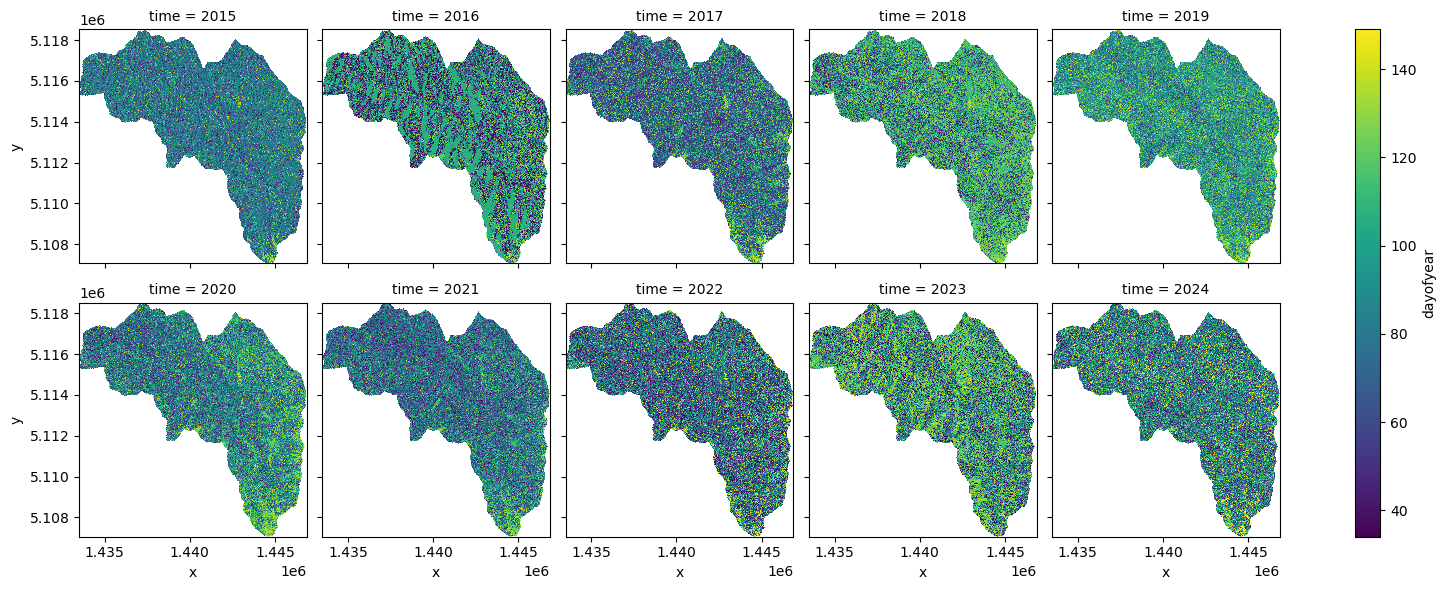

In [6]:
# compile geotiff list
geotiff_list = glob.glob(f'output_vv_10/runoff_onset_2*_vv_10.tif')

# make list of each year 
year_list = []
# iterate through geotiffs and append to year list
for geotiff in geotiff_list:
    year_list.append(re.search("([0-9]{4})", geotiff).group(0))
year_list = [int(year) for year in year_list]

# create variable used for time axis
time_var = xr.Variable('time', year_list)

# Load in and concatenate all individual GeoTIFFs
runoffs_allyears_vv_10 = xr.concat([rxr.open_rasterio(i) for i in geotiff_list],dim=time_var).squeeze().sortby('time')

# plot all years
runoffs_allyears_vv_10.plot(col='time',col_wrap=5)
# save figure 
plt.savefig("runoff_allyears_vv_10", dpi=300)

# meadian
#runoffs_allyears_median = runoffs_allyears.median(dim='time')
# standard deviation
#runoffs_allyears_std = runoffs_allyears.std(dim='time')
# polyfit
#polyfits = runoffs_allyears.polyfit('time',deg=1,full=True,cov=True)
# polyfit coefficeient 
#runoffs_allyears_corr = polyfits.polyfit_coefficients[0].rio.set_crs(runoffs_allyears.rio.crs)
# correlation stregth
#runoffs_allyears_corr_strength = xr.corr(runoffs_allyears.time,runoffs_allyears,dim='time').rio.set_crs(runoffs_allyears.rio.crs)


In [8]:
# convert to median day of melt raster
runoffs_allyears_median.rio.to_raster(f'output_vv/runoff_onset_allyears_median_{res}m.tif')

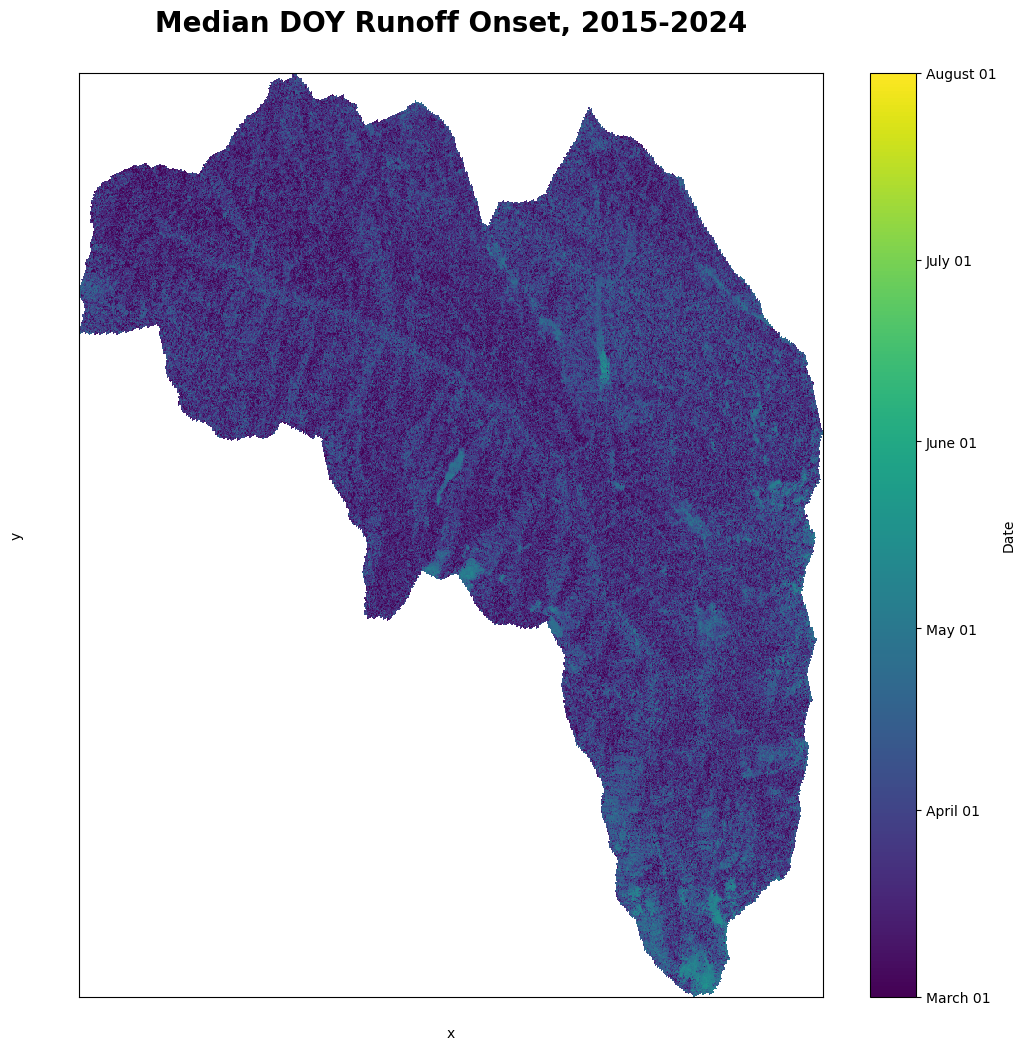

In [9]:
#plot median runoff DOY all years
f,ax=plt.subplots(figsize=(12,12))
# plot 
im = runoffs_allyears_median.plot(ax=ax,vmin=61,vmax=214,add_colorbar=False)

# make variable for date range for months of the year
s = pd.Series(pd.date_range("2020-1-1", periods=12, freq=pd.offsets.MonthBegin(1)))

# make a color bar with ticks 
cb = plt.colorbar(im, ticks=s.dt.dayofyear)
# tick labels for first of month
cb.ax.set_yticklabels(s.dt.strftime(date_format='%B %d'))
# label indicating color bar represents date
cb.set_label(label='Date') 

ax.set_title('Median DOY Runoff Onset, 2015-2024', pad = 30, fontsize= 20, fontweight ='bold')
ax.tick_params(left = False, bottom = False, labelcolor='white')

# save figure 
plt.savefig("full_runoff", dpi=300)

/tmp/ipykernel_2096271/3878125676.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


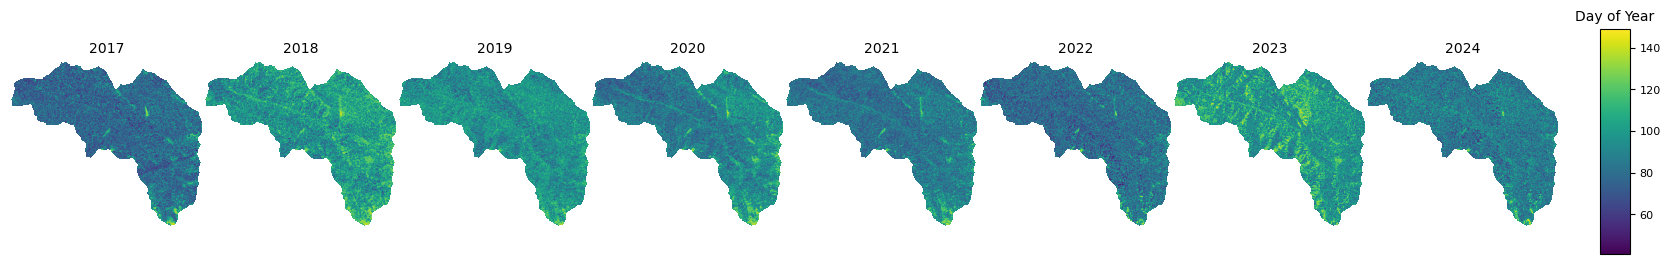

In [16]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import re

def plot_last_8_rasters(raster_paths, output_path="last_8_rasters_row.png", figure_size=(20, 5)):
    """
    Plot the last 8 rasters in one row and save the figure to a file, with no axes.
    
    Args:
        raster_paths (list of str): List of file paths to the raster files.
        output_path (str): File path for saving the output figure.
        figure_size (tuple): Size of the figure (width, height).
    """
    # Ensure there are at least 8 rasters in the list
    if len(raster_paths) < 8:
        raise ValueError("This function requires at least 8 rasters.")

    # Extract years from file names using regex
    titles = []
    for raster_path in raster_paths:
        match = re.search(r'(\d{4})', raster_path)  # Look for a 4-digit year
        if match:
            titles.append(match.group(1))  # Add the year to the titles list
        else:
            titles.append("Unknown")  # Fallback if no year is found

    # Create the figure (2 rows, 4 columns)
    fig, axes = plt.subplots(1, 8, figsize=figure_size, gridspec_kw={'wspace': 0, 'hspace': 0.2})
    axes = axes.flatten()  # Flatten axes for easier iteration
    
    # Plot each raster in its corresponding subplot
    for i, (raster_path, ax) in enumerate(zip(raster_paths, axes)):
        with rasterio.open(raster_path) as src:
            # Read the raster data
            raster_data = src.read(1)
            raster_data = np.ma.masked_equal(raster_data, src.nodata)  # Mask NoData values if present
            
        # Display the raster
        im = ax.imshow(raster_data, cmap='viridis')  # Use a colormap (e.g., 'viridis')
        ax.axis('off')  # Remove axes for a cleaner look
        

        # Add the year as the title
        ax.set_title(titles[i], fontsize=10)

    # Add a shared color bar to the right of the figure
    cbar_ax = fig.add_axes([0.92, 0.275, 0.015, 0.45])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
    cbar.ax.set_title("Day of Year", fontsize=10)  # Label for the color bar
    cbar.ax.tick_params(labelsize=8)  # Adjust tick size
    
    # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig("clean_vv10_allyears_runoff", bbox_inches='tight', dpi=300)
    #plt.close()
    #print(f"Saved figure with last 8 rasters to {output_path}")
    plt.show()
    
# Example usage
raster_paths = [
    "output_vv_10/runoff_onset_2017_vv_10.tif", 
    "output_vv_10/runoff_onset_2018_vv_10.tif",
    "output_vv_10/runoff_onset_2019_vv_10.tif",
    "output_vv_10/runoff_onset_2020_vv_10.tif",
    "output_vv_10/runoff_onset_2021_vv_10.tif",
    "output_vv_10/runoff_onset_2022_vv_10.tif",
    "output_vv_10/runoff_onset_2023_vv_10.tif",
    "output_vv_10/runoff_onset_2024_vv_10.tif"
]

plot_last_8_rasters(raster_paths)


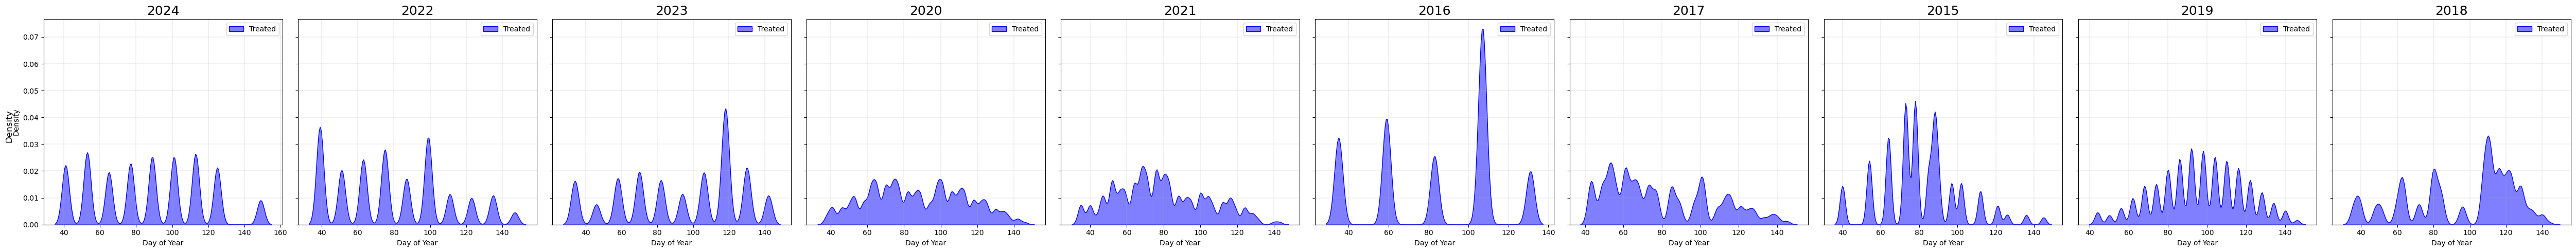

In [1]:
import os
import re
import numpy as np
import rasterio
import seaborn as sns
import matplotlib.pyplot as plt 

# Loads rasters
def load_raster(file_path):
    with rasterio.open(file_path) as src:
        raster = src.read(1)  # Read the first band
        nodata_value = src.nodata  # Get NoData value if available
    return raster, nodata_value

# Extracts year of rasters from file names
def get_rasters_by_year(folder_path):
    rasters_by_year = {}
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".tif"):
            match = re.search(r'(\d{4})', file_name)  # Extract year from the filename
            if match:
                year = match.group(1)
                rasters_by_year[year] = os.path.join(folder_path, file_name)
    return rasters_by_year

# Plot KDE for each year in the folder
def plot_kde_for_each_year(folder, output_path="kde_per_year.png", figure_size=None):
    rasters = get_rasters_by_year(folder)

    if not rasters:
        raise ValueError(f"No rasters found in the folder {folder}. Please check your folder path.")

    # Set figure size
    if figure_size is None:
        figure_size = (5 * len(rasters), 5)  # 5 units of width per subplot, height 5

    fig, axes = plt.subplots(1, len(rasters), figsize=figure_size, sharey=True)

    # Loop over each year
    for ax, (year, raster_path) in zip(axes, rasters.items()):
        raster, nodata = load_raster(raster_path)

        # Flatten the raster and remove NoData values
        raster_values = raster.flatten()
        if nodata is not None:
            raster_values = raster_values[raster_values != nodata]  # Remove NoData

        # Plot the KDE for the year
        sns.kdeplot(raster_values, ax=ax, fill=True, color="blue", alpha=0.5, label="Treated")

        # Format plots
        ax.set_title(year, fontsize=18)
        ax.set_xlabel("Day of Year")
        ax.set_ylabel("Density")
        ax.grid(linewidth=0.25)
        ax.legend(loc="upper right", fontsize=10)

    fig.text(0.0, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    plt.show()

# Example usage
folder = "output_vv_10"  # Change to your folder path containing the rasters
plot_kde_for_each_year(folder, output_path="kde_per_year.png")


/tmp/ipykernel_2016131/885542817.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_smoothed = y_series.rolling(window=window_size, center=True).mean().fillna(method="bfill").fillna(method="ffill")


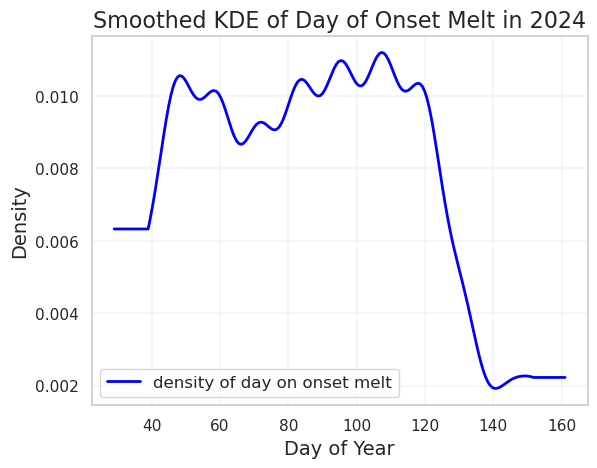

In [18]:
import numpy as np
import rasterio
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd  # For smoothing with a rolling average

# Load raster data
def load_raster(file_path):
    with rasterio.open(file_path) as src:
        raster = src.read(1)  # Read the first band
        nodata_value = src.nodata  # Get NoData value if available
    return raster, nodata_value

# Smooths a density curve using a rolling average
def smooth_density(x, y, window_size=30):
    y_series = pd.Series(y)
    y_smoothed = y_series.rolling(window=window_size, center=True).mean().fillna(method="bfill").fillna(method="ffill")
    return x, y_smoothed
    
# File paths to your raster datasets
raster1_path = "output_vv_10/runoff_onset_2024_vv_10.tif"

# Load the rasters
raster1, nodata1 = load_raster(raster1_path)

# Flatten the rasters and remove NoData values
raster1_values = raster1.flatten()

if nodata1 is not None:
    raster1_values = raster1_values[raster1_values != nodata1]  # Remove NoData

# Set bandwidth adjustment to control the smoothness
sns.set(style="whitegrid")  # Optional for nicer background

# Plot the raw KDEs and extract the line objects
kde1 = sns.kdeplot(raster1_values, bw_adjust=2, label="Treated", color="blue", alpha=0.5)

# Extract KDE lines for treated and untreated
x1, y1 = kde1.get_lines()[0].get_data()

# Smooth the density curves
x1_smooth, y1_smooth = smooth_density(x1, y1, window_size=30)

# Clear the figure to avoid drawing duplicate plots
plt.clf()

# Plot the smoothed lines only
plt.plot(x1_smooth, y1_smooth, color="blue", label="density of day on onset melt", lw=2)

# Add titles and labels
plt.title("Smoothed KDE of Day of Onset Melt in 2024", fontsize=16)
plt.xlabel("Day of Year", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=12)
plt.grid(linewidth=0.25)

# Show the plot
plt.show()
#plt.savefig("smoothed_treatmentPDF_2020.png", bbox_inches="tight", dpi=300)


Processing file: runoff_onset_2017_vv_10.tif


/tmp/ipykernel_1887462/3320611385.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_smoothed = y_series.rolling(window=window_size, center=True).mean().fillna(method="bfill").fillna(method="ffill")


Processing file: runoff_onset_2018_vv_10.tif
Processing file: runoff_onset_2019_vv_10.tif
Processing file: runoff_onset_2020_vv_10.tif
Processing file: runoff_onset_2021_vv_10.tif
Processing file: runoff_onset_2022_vv_10.tif
Processing file: runoff_onset_2023_vv_10.tif
Processing file: runoff_onset_2024_vv_10.tif


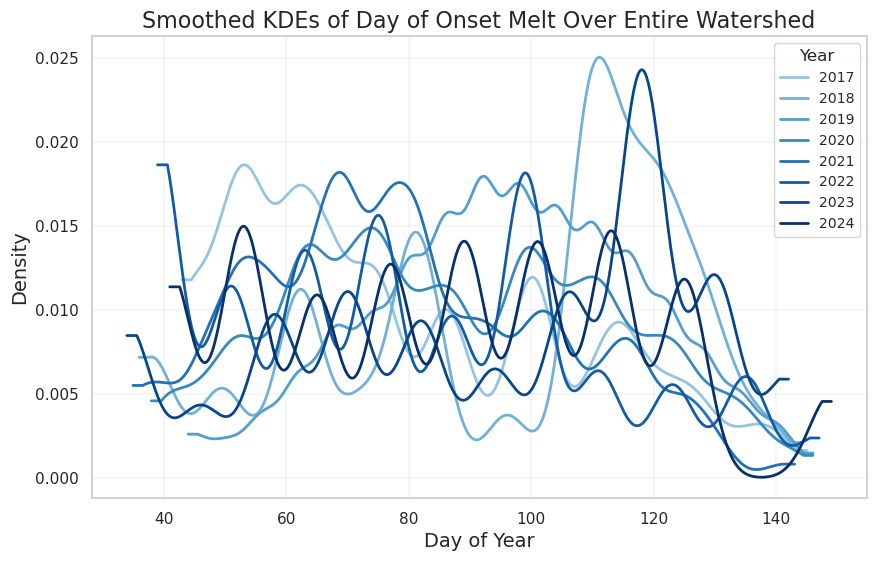

In [11]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd  # For smoothing with a rolling average
from matplotlib import cm  # For generating color shades
from scipy.stats import gaussian_kde  # For explicit KDE computation

# Load raster data
def load_raster(file_path):
    with rasterio.open(file_path) as src:
        raster = src.read(1)  # Read the first band
        nodata_value = src.nodata  # Get NoData value if available
    return raster, nodata_value

# Smooths a density curve using a rolling average
def smooth_density(x, y, window_size=30):
    y_series = pd.Series(y)
    y_smoothed = y_series.rolling(window=window_size, center=True).mean().fillna(method="bfill").fillna(method="ffill")
    return x, y_smoothed

# Define the folder path
folder_path = "output_vv_10"

# Get the sorted list of .tif files and select the last 8
files = sorted([f for f in os.listdir(folder_path) if f.endswith(".tif")])[-8:]

# Generate a colormap with different shades of blue
colors = cm.Blues(np.linspace(0.4, 1, len(files)))

# Set the style for the plot
plt.figure(figsize=(10, 6))

# Iterate through the last 8 files and compute KDE explicitly
for idx, file_name in enumerate(files):
    file_path = os.path.join(folder_path, file_name)
    print(f"Processing file: {file_name}")

    # Extract the year from the file name (assumes format: runoff_onset_YYYY_vv_10.tif)
    year = file_name.split("_")[2]

    # Load raster data
    raster, nodata = load_raster(file_path)
    raster_values = raster.flatten()

    # Remove NoData values
    if nodata is not None:
        raster_values = raster_values[raster_values != nodata]

    # Remove any remaining NaN or Inf values
    raster_values = raster_values[np.isfinite(raster_values)]

    # Skip the file if no valid values remain
    if raster_values.size == 0:
        print(f"Skipping {file_name} due to lack of valid data.")
        continue

    # Compute bandwidth to match sns.kdeplot behavior
    bandwidth = 1.75 * np.std(raster_values) * raster_values.size ** (-1 / 5)  # Silverman's rule of thumb
    kde = gaussian_kde(raster_values, bw_method=bandwidth / np.std(raster_values))  # Adjust KDE bandwidth

    # Generate KDE data
    x = np.linspace(raster_values.min(), raster_values.max(), 1000)
    y = kde(x)

    # Smooth the density curves
    x_smooth, y_smooth = smooth_density(x, y, window_size=30)

    # Plot only the smoothed lines
    plt.plot(x_smooth, y_smooth, color=colors[idx], label=f"{year}", lw=2)

# Add titles and labels
plt.title("Smoothed KDEs of Day of Onset Melt Over Entire Watershed", fontsize=16)
plt.xlabel("Day of Year", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=10, title="Year", title_fontsize=12, loc='upper right')
plt.grid(linewidth=0.25)

# Show the plot
plt.show()


Reprojecting shapefile from EPSG:26712 to EPSG:32610


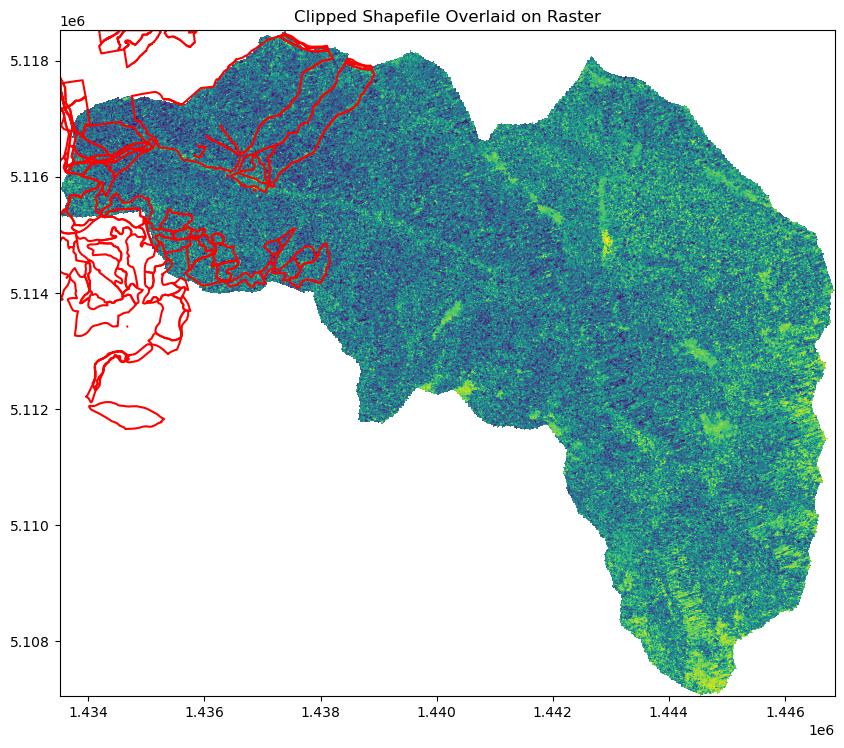

In [8]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
from shapely.geometry import box

# File paths
raster_path = "output_vv_10/runoff_onset_2020_vv_10.tif"
shapefile_path = "treatment_shp"

# Load raster and get its CRS and bounds
with rasterio.open(raster_path) as src:
    raster_crs = src.crs  # Get CRS of raster
    raster_bounds = box(*src.bounds)  # Create a bounding box from raster extent
    fig, ax = plt.subplots(figsize=(10, 10))
    show(src, ax=ax)  # Plot the raster

# Load shapefile
gdf = gpd.read_file(shapefile_path)

# Reproject shapefile if needed
if gdf.crs != raster_crs:
    print(f"Reprojecting shapefile from {gdf.crs} to {raster_crs}")
    gdf = gdf.to_crs(raster_crs)

# Clip shapefile to raster extent
gdf_clipped = gpd.clip(gdf, raster_bounds)

# Overlay the clipped shapefile
gdf_clipped.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1.5)

# Show the final plot
plt.title("Clipped Shapefile Overlaid on Raster")
plt.show()


Reprojecting reference shapefile from EPSG:4326 to EPSG:32610
Reprojecting shapefile to clip from EPSG:26712 to EPSG:32610


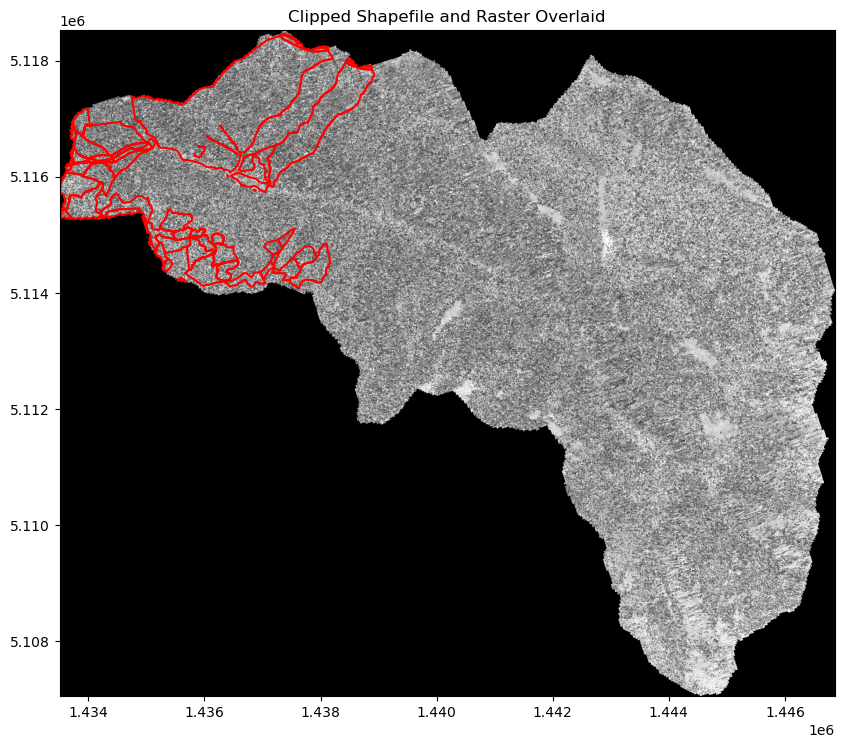

In [9]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.mask import mask
from rasterio.plot import show
from shapely.geometry import mapping

# File paths
reference_shapefile_path = "watershed_shp"

raster_path = "output_vv_10/runoff_onset_2020_vv_10.tif"
shapefile_to_clip_path = "treatment_shp"

# Load reference shapefile (the one we are clipping to)
reference_gdf = gpd.read_file(reference_shapefile_path)

# Load the raster
with rasterio.open(raster_path) as src:
    raster_crs = src.crs  # Get raster CRS

# Reproject reference shapefile if needed
if reference_gdf.crs != raster_crs:
    print(f"Reprojecting reference shapefile from {reference_gdf.crs} to {raster_crs}")
    reference_gdf = reference_gdf.to_crs(raster_crs)

# Load the shapefile that needs to be clipped
gdf_to_clip = gpd.read_file(shapefile_to_clip_path)

# Reproject the shapefile to be clipped if needed
if gdf_to_clip.crs != raster_crs:
    print(f"Reprojecting shapefile to clip from {gdf_to_clip.crs} to {raster_crs}")
    gdf_to_clip = gdf_to_clip.to_crs(raster_crs)

# Clip the shapefile to the reference shapefile
gdf_clipped = gpd.clip(gdf_to_clip, reference_gdf)

# Clip the raster to the reference shapefile
with rasterio.open(raster_path) as src:
    reference_geometry = [mapping(geom) for geom in reference_gdf.geometry]  # Convert to GeoJSON format
    clipped_raster, clipped_transform = mask(src, reference_geometry, crop=True)
    
    # Update metadata for the clipped raster
    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "transform": clipped_transform,
        "width": clipped_raster.shape[2],
        "height": clipped_raster.shape[1]
    })

# Plot the clipped raster and clipped shapefile
fig, ax = plt.subplots(figsize=(10, 10))
show(clipped_raster, transform=clipped_transform, ax=ax, cmap="gray")  # Plot the clipped raster
gdf_clipped.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1.5)  # Overlay clipped shapefile



# Show the final plot
plt.title("Clipped Shapefile and Raster Overlaid")
plt.show()


ERROR 1: PROJ: proj_create_from_database: Open of /mnt/shared/moduleapps/EarthSci/Python-3.9.15-Mamba/share/proj failed


Reprojecting reference shapefile from EPSG:4326 to EPSG:32610
Reprojecting shapefile to clip from EPSG:26712 to EPSG:32610


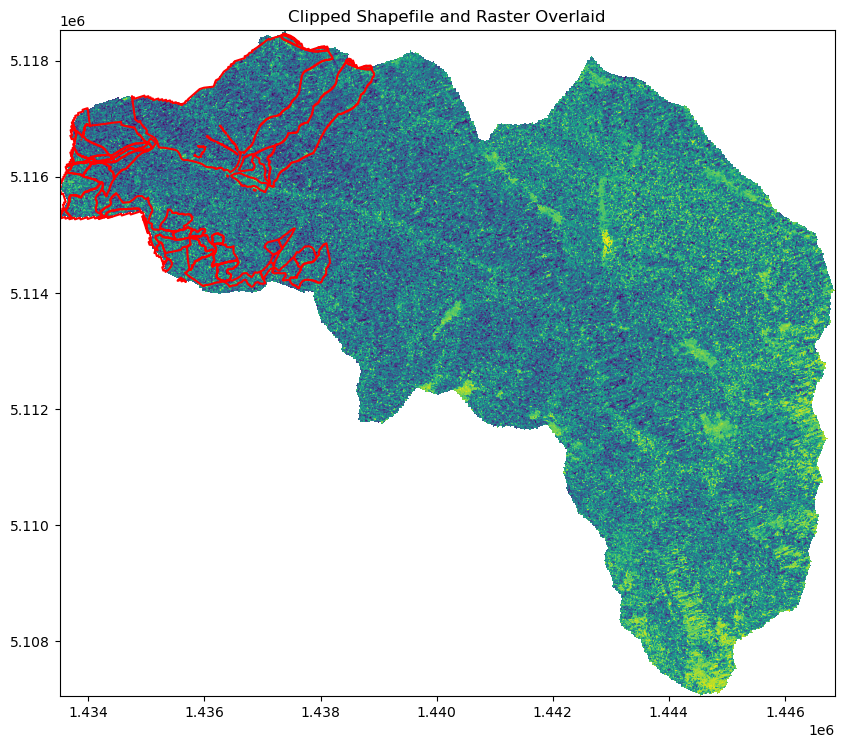

In [2]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.mask import mask
from rasterio.plot import show
from shapely.geometry import mapping

# File paths
reference_shapefile_path = "watershed_shp"
raster_path = "output_vv_10/runoff_onset_2020_vv_10.tif"
shapefile_to_clip_path = "treatment_shp"

# Load reference shapefile (the one we are clipping to)
reference_gdf = gpd.read_file(reference_shapefile_path)

# Load the raster
with rasterio.open(raster_path) as src:
    raster_crs = src.crs  # Get raster CRS

# Reproject reference shapefile if needed
if reference_gdf.crs != raster_crs:
    print(f"Reprojecting reference shapefile from {reference_gdf.crs} to {raster_crs}")
    reference_gdf = reference_gdf.to_crs(raster_crs)

# Load the shapefile that needs to be clipped
gdf_to_clip = gpd.read_file(shapefile_to_clip_path)

# Reproject the shapefile to be clipped if needed
if gdf_to_clip.crs != raster_crs:
    print(f"Reprojecting shapefile to clip from {gdf_to_clip.crs} to {raster_crs}")
    gdf_to_clip = gdf_to_clip.to_crs(raster_crs)

# Clip the shapefile to the reference shapefile
gdf_clipped = gpd.clip(gdf_to_clip, reference_gdf)

# Clip the raster to the reference shapefile
with rasterio.open(raster_path) as src:
    reference_geometry = [mapping(geom) for geom in reference_gdf.geometry]  # Convert to GeoJSON format
    clipped_raster, clipped_transform = mask(src, reference_geometry, crop=True)

    # Replace nodata values (assumed to be 0) with NaN for transparency
    clipped_raster = np.where(clipped_raster == 0, np.nan, clipped_raster)

    # Update metadata for the clipped raster
    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "transform": clipped_transform,
        "width": clipped_raster.shape[2],
        "height": clipped_raster.shape[1]
    })

# Plot the clipped raster and clipped shapefile
fig, ax = plt.subplots(figsize=(10, 10))
show(clipped_raster, transform=clipped_transform, ax=ax, cmap="viridis", vmin=np.nanmin(clipped_raster), vmax=np.nanmax(clipped_raster))

# Overlay clipped shapefile
gdf_clipped.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1.5)

# Show the final plot
plt.title("Clipped Shapefile and Raster Overlaid")
plt.show()
